ALUMNOS: LUCIA FLORENCIA SANCHEZ Y CARLOS GABRIEL SANCHEZ

# **ACTIVIDAD 5**

In [ ]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski


def mostrar_imagenes(imagenes, titulos, cmap=None, figsize=(14, 4)):
    fig, axes = plt.subplots(1, len(imagenes), figsize=figsize)
    if len(imagenes) == 1:
        axes = [axes]

    for ax, imagen, titulo in zip(axes, imagenes, titulos):
        if imagen.ndim == 2:
            ax.imshow(imagen, cmap=cmap or "gray")
        else:
            ax.imshow(imagen)
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def segmentar_por_umbral(imagen, umbral):
    mascara = np.zeros_like(imagen, dtype=np.uint8)
    mascara[imagen > umbral] = 255
    return mascara

In [ ]:
base = Path(".")

cv2.imwrite(str(base / "paisaje.png"), cv2.cvtColor(ski.data.astronaut(), cv2.COLOR_RGB2BGR))
cv2.imwrite(str(base / "texto.png"), ski.data.page())
cv2.imwrite(str(base / "monedas.png"), ski.data.coins())

print("Archivos de práctica listos: paisaje.png, texto.png y monedas.png")

Archivos de práctica listos: paisaje.png, texto.png y monedas.png


<br>

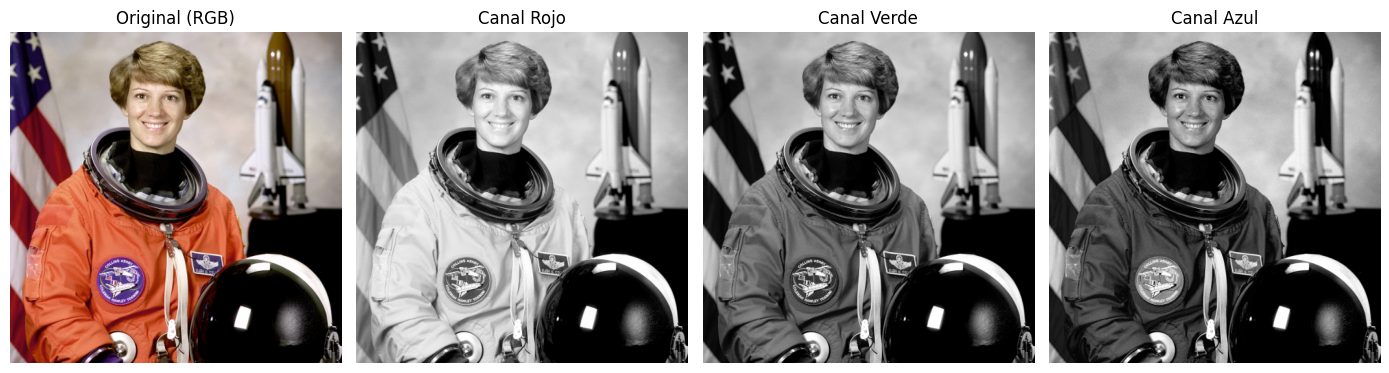

In [ ]:
# 1. Cargar la imagen
img_bgr = cv2.imread("paisaje.png")

# 2. Convertirla a RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Extraer canales
# OpenCV almacena las imágenes en formato BGR por defecto. Al convertir a RGB,
# los canales se organizan como [R, G, B].
canal_rojo = img_rgb[:, :, 0]  # El primer canal es el Rojo
canal_verde = img_rgb[:, :, 1] # El segundo canal es el Verde
canal_azul = img_rgb[:, :, 2]  # El tercer canal es el Azul

# 4. Visualizar resultados
mostrar_imagenes(
    [img_rgb, canal_rojo, canal_verde, canal_azul],
    ["Original (RGB)", "Canal Rojo", "Canal Verde", "Canal Azul"],
    cmap="gray" # Usamos 'gray' para los canales individuales para ver su intensidad
)

<br>

### Observaciones sobre los Canales de Color en `paisaje.png` (Astronauta):

Al analizar los canales de color por separado, podemos observar:

*   **Canal Rojo:** los lugares donde el rojo tiene mas presencia, (traje, piel ) aparecen más brillantes. Las zonas con poca presencia de rojo (como el fondo azul oscuro) se ven más oscuras.

*   **Canal Verde:** no hay verde en esta imagen, todo lo que antes se veia iluminado en el canal rojo aqui se ve mas oscuro, tanto el azul como el naranja del traje o la piel.

*   **Canal Azul:** los lugares azules se ven iluminados (escudo) el resto se ve muy oscuro.

<br>

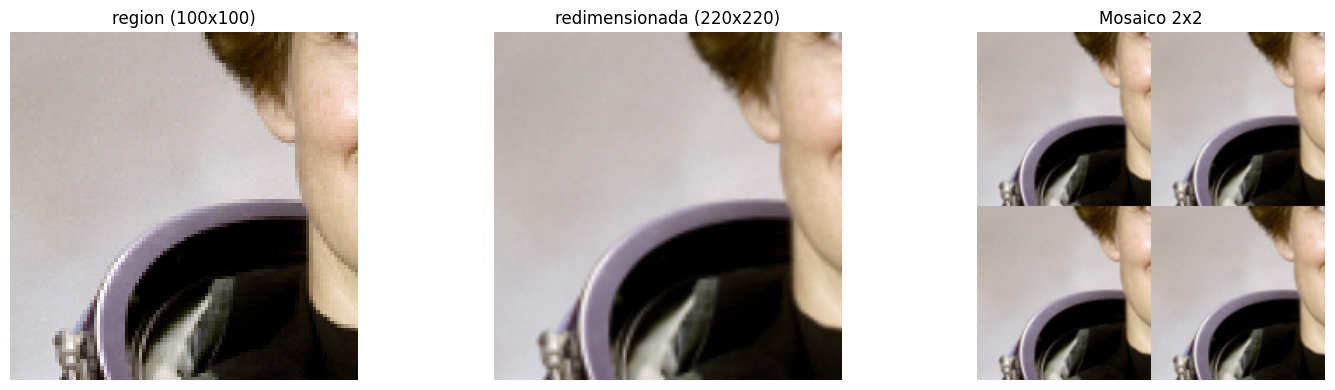

In [ ]:
# región de interés de 100x100 píxeles, desde (100, 100) hasta (200, 200).
y1, y2 = 100, 200
x1, x2 = 100, 200

region = img_rgb[y1:y2, x1:x2]
region_redimensionada = cv2.resize(region, (220, 220))

# mosaico 2 x 2.
# Para crear un mosaico 2x2, duplicamos la imagen redimensionada y la apilamos horizontal y verticalmente.
fila_superior = np.hstack((region_redimensionada, region_redimensionada))
fila_inferior = np.hstack((region_redimensionada, region_redimensionada))
mosaico = np.vstack((fila_superior, fila_inferior))

mostrar_imagenes(
    [region, region_redimensionada, mosaico],
    ["region (100x100)", "redimensionada (220x220)", "Mosaico 2x2"],
    figsize=(15, 4),
)

<br>

Recortar y Redimensionar

Cuando recorto selecciono una region de la imagen, descarto el resto. El tamaño de cada pixel no cambia, al redimensionar, cambio las dimensiones, a lo alto y ancho de la imagen, se modifica el tamaño de los pixeles o se interpolan nuevos pixeles para ajustar la imagen a las nuevas dimensiones. Es como estirar toda la imagen para que quepa en un marco diferente.

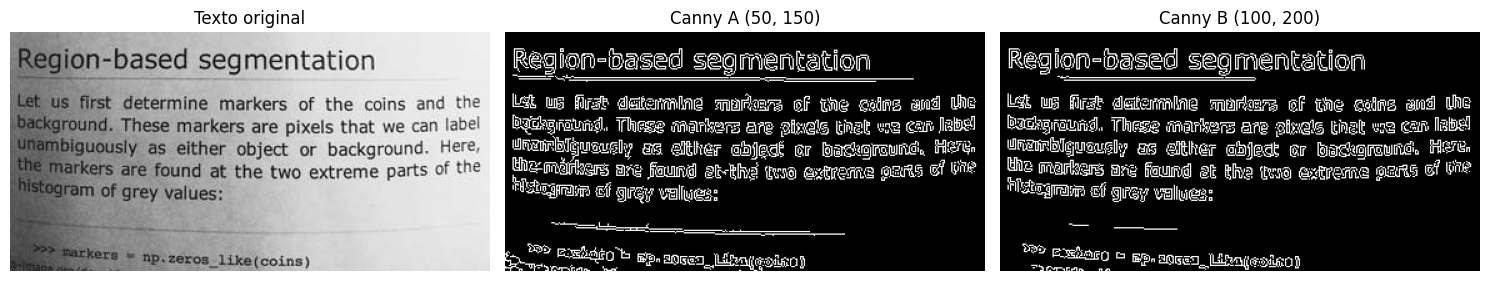

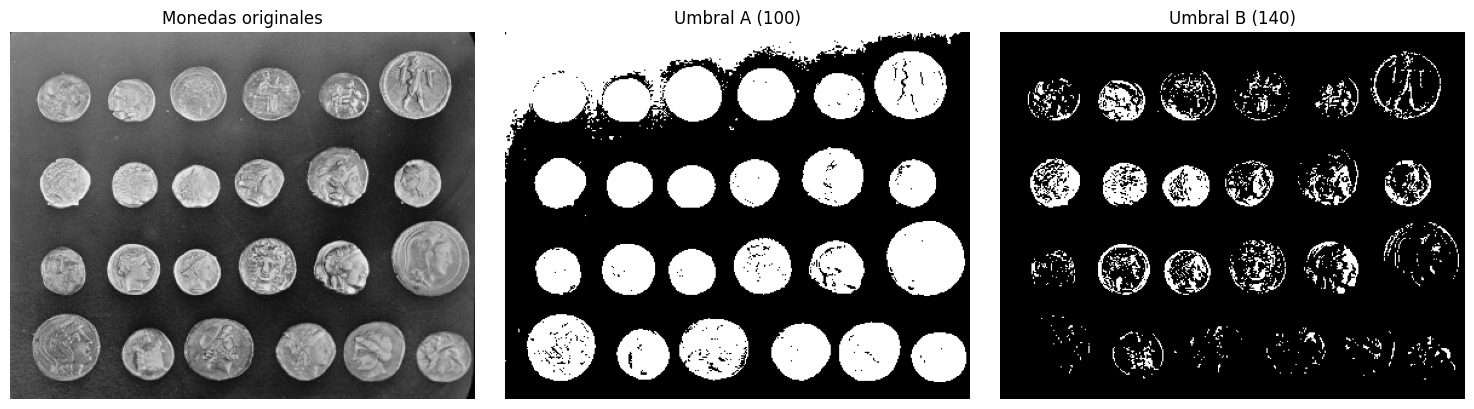

In [ ]:
img_texto = cv2.imread("texto.png", cv2.IMREAD_GRAYSCALE)


canny_a = cv2.Canny(img_texto, 50, 150)  # resaltar detalles
canny_b = cv2.Canny(img_texto, 100, 200) # resaltar bordes

mostrar_imagenes(
    [img_texto, canny_a, canny_b],
    ["Texto original", "Canny A (50, 150)", "Canny B (100, 200)"],
    figsize=(15, 4),
)

img_monedas = cv2.imread("monedas.png", cv2.IMREAD_GRAYSCALE)


seg_a = segmentar_por_umbral(img_monedas, 100) # Umbral bajo
seg_b = segmentar_por_umbral(img_monedas, 180) # Umbral alto

mostrar_imagenes(
    [img_monedas, seg_a, seg_b],
    ["Monedas originales", "Umbral A (100)", "Umbral B (140)"],
    figsize=(15, 4),
)

<br>

Con umbrales más bajos, se detectan más bordes, incluidos detalles finos y transiciones suaves que no son bordes fuertes. Esto puede ser útil por ejemplo, para OCR en texto muy fino.

Con umbrales más altos, solo se detectan los bordes más fuertes y prominentes. Esto ayuda a eliminar el ruido y a simplificar la estructura del texto, lo que podría ser preferible para tareas donde se necesita una representación limpia de los caracteres o para reducir la complejidad computacional en etapas posteriores. En este caso, Canny B parece ofrecer una detección de bordes del texto más clara y menos ruidosa, lo que lo hace más útil para identificar los contornos principales de los caracteres.

para las monedas, con umbrales bajos se visualizan bien los dibujos de las primeras monedas, con umbrales altos, se visualizan mejor las ultimas monedas, si variamos el umbral podemos ir viendo los dibujos de todas.

Conviene mirar los canales por separado cuando necesitas analizar la composición cromática de una imagen o realzar características específicas que son más prominentes en uno de los canales. Por ejemplo:

Para entender cómo contribuye cada color a la imagen final.
Para detectar objetos que tienen una fuerte dominancia en un color particular (ej. vegetación en el canal verde, sangre o piel en el canal rojo).
Para la pre-procesamiento en tareas de segmentación o detección, donde un canal puede ofrecer mejor contraste para el objeto de interés.
El algoritmo Canny utiliza dos umbrales (un umbral bajo y un umbral alto) para la detección de bordes. Al modificarlos:
Umbral bajo: Determina el punto en el que un gradiente de intensidad es considerado un posible borde. Si es muy bajo, se detectan más bordes, incluyendo aquellos que son débiles o ruido.
Umbral alto: Define el punto en el que un gradiente de intensidad es definitivamente un borde. Los bordes fuertes deben ser mayores que este umbral.
Relación entre umbrales: El algoritmo conecta los bordes fuertes a los posibles bordes (entre los dos umbrales) si están conectados a un borde fuerte. Un umbral bajo más permisivo con un umbral alto restrictivo puede ayudar a conectar segmentos de bordes. Si ambos umbrales son bajos, se obtendrán muchos bordes y ruido; si ambos son altos, se perderán muchos bordes y solo se conservarán los más prominentes.
¿Por qué una segmentación por umbral puede funcionar bien en una imagen y mal en otra? La segmentación por umbral funciona bien cuando hay una clara distinción de intensidad entre el objeto de interés y el fondo. Es decir, los píxeles del objeto son consistentemente más claros (o más oscuros) que los píxeles del fondo. Sin embargo, puede fallar o funcionar mal en imágenes donde:

Iluminación inconsistente: La iluminación no es uniforme, haciendo que el mismo objeto tenga diferentes intensidades en distintas partes de la imagen.
Fondo complejo o similar: El fondo tiene intensidades de píxeles similares a las del objeto, o es muy variado.
Variabilidad intrínseca del objeto: El objeto en sí mismo tiene una amplia gama de intensidades, lo que hace difícil encontrar un único umbral que lo separe completamente del fondo.
Imágenes con poco contraste: Hay poca diferencia de intensidad entre el objeto y el fondo, lo que hace que cualquier umbral sea arbitrario o ineficaz.



---

<br>


## **ACTIVIDAD 7**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo abrir la imagen: {ruta}")
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_imagen(imagen, titulo="Imagen"):
    plt.figure(figsize=(6, 6))
    plt.imshow(imagen, cmap="gray" if imagen.ndim == 2 else None)
    plt.title(titulo)
    plt.axis("off")
    plt.show()


def mostrar_comparacion(original, procesada, titulo_original="Original", titulo_procesada="Procesada"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original, cmap="gray" if original.ndim == 2 else None)
    axes[0].set_title(titulo_original)
    axes[0].axis("off")

    axes[1].imshow(procesada, cmap="gray" if procesada.ndim == 2 else None)
    axes[1].set_title(titulo_procesada)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


def ajustar_brillo_contraste(imagen_rgb, alpha=1.2, beta=10):
    return cv2.convertScaleAbs(imagen_rgb, alpha=alpha, beta=beta)


def suavizar(imagen_rgb, kernel=5):
    return cv2.GaussianBlur(imagen_rgb, (kernel, kernel), 0)


def mejorar_contraste_clahe(imagen_rgb, clip_limit=2.0, tile=8):
    imagen_lab = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(imagen_lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))
    l_mejorado = clahe.apply(l)
    imagen_lab_mejorada = cv2.merge((l_mejorado, a, b))
    return cv2.cvtColor(imagen_lab_mejorada, cv2.COLOR_LAB2RGB)


def mostrar_histograma_gris(imagen_rgb):
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    hist, bins = np.histogram(gris.flatten(), bins=256, range=[0, 256])
    plt.figure(figsize=(10, 4))
    plt.plot(bins[:-1], hist, color="black")
    plt.title("Histograma en escala de grises")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()

Ruta del notebook detectada: /content/drive/MyDrive/procesamiento digital de imagenes
Archivo cargado: /content/drive/MyDrive/procesamiento digital de imagenes/CAMARA-OSCURA-2.jpeg
Forma: (105, 100, 3)
Tipo de dato: uint8


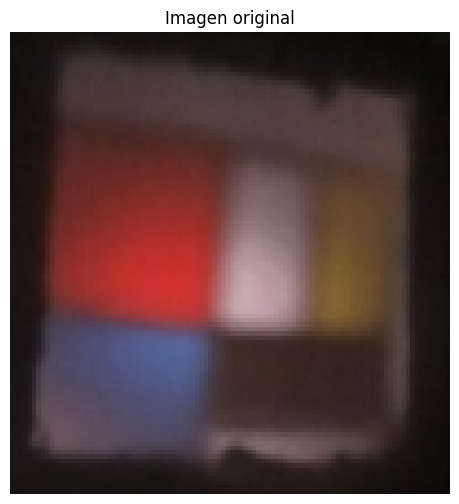

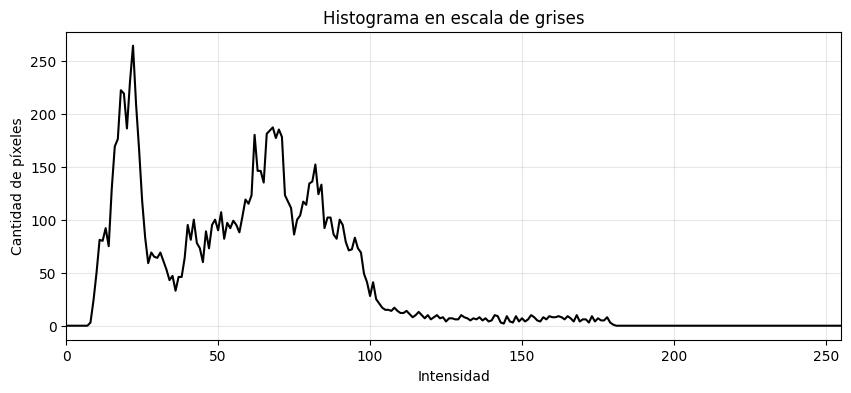

Archivo cargado: /content/drive/MyDrive/procesamiento digital de imagenes/CAMARA-OSCURA-1.jpeg
Forma: (150, 135, 3)
Tipo de dato: uint8


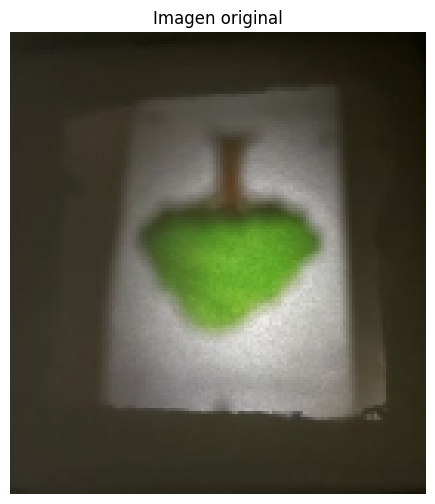

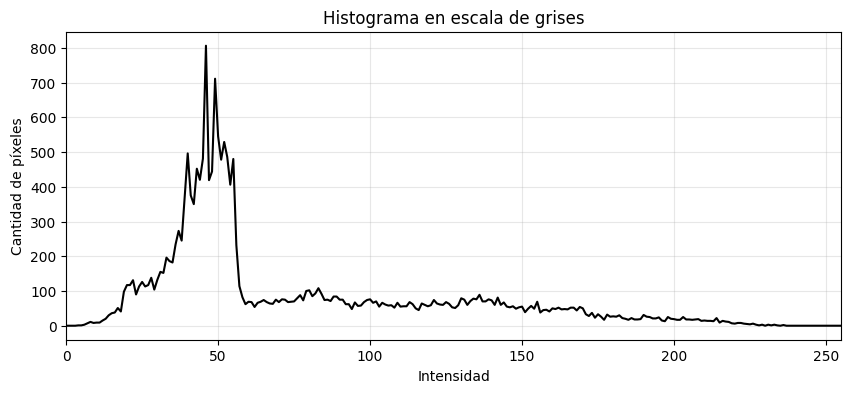

In [ ]:
# Define la ruta a tu carpeta en Google Drive donde está el notebook y la imagen.
# Por defecto, asumimos que está en la raíz de 'Mi unidad' o dentro de 'Colab Notebooks'.
# Ajusta esta ruta si tu notebook está en otro lugar.
# Por ejemplo: folder_path = Path('/content/drive/MyDrive/Mi_Carpeta_De_Colab')

# La siguiente línea intenta determinar la ruta del notebook actual. Si falla, usa un valor por defecto.
try:
    # Obtener el directorio de trabajo actual (donde se ejecuta el notebook)
    # notebook_dir = Path.cwd()
    # Construir la ruta a la imagen asumiendo que está en el mismo directorio
    # folder_path = notebook_dir
    folder_path = Path('/content/drive/MyDrive/procesamiento digital de imagenes') # Asumiendo la ruta por defecto a Google Drive
    print(f"Ruta del notebook detectada: {folder_path}")
except Exception as e:
    print(f"No se pudo determinar la ruta del notebook automáticamente: {e}")
    print("Asumiendo la ruta por defecto: /content/drive/MyDriveprocesamiento digital de imagenes")
    folder_path = Path('/content/drive/MyDrive/') # Ruta por defecto si no se puede detectar

# Modificamos la variable nombre_imagen para que sea una ruta completa dentro de Drive
nombre_imagen = str(folder_path / "CAMARA-OSCURA-2.jpeg")
ruta = Path(nombre_imagen)

# Ahora, el resto del código puede usar esta 'ruta' actualizada.
imagen_original2 = cargar_rgb(ruta)

print(f"Archivo cargado: {ruta}")
print(f"Forma: {imagen_original2.shape}")
print(f"Tipo de dato: {imagen_original2.dtype}")

mostrar_imagen(imagen_original2, "Imagen original")
mostrar_histograma_gris(imagen_original2)

# Modificamos la variable nombre_imagen para que sea una ruta completa dentro de Drive
nombre_imagen = str(folder_path / "CAMARA-OSCURA-1.jpeg")
ruta = Path(nombre_imagen)

# Ahora, el resto del código puede usar esta 'ruta' actualizada.
imagen_original1 = cargar_rgb(ruta)

print(f"Archivo cargado: {ruta}")
print(f"Forma: {imagen_original1.shape}")
print(f"Tipo de dato: {imagen_original1.dtype}")

mostrar_imagen(imagen_original1, "Imagen original")
mostrar_histograma_gris(imagen_original1)

`CAMARA-OSCURA-2.jpeg`:**

La imagen  se ve oscura** y tiene poco contraste.
El histograma esta concentrado en el lado izquierdo (valores de intensidad bajos), indicando que la mayoría de los píxeles son oscuros. Además, la mayoria de los pixeles no se extienden por todo el rango de 0 a 255, esto sugiere un bajo contraste, donde no hay una gran diferencia entre las partes más claras y más oscuras de la imagen.

`CAMARA-OSCURA-1.jpeg`

Similar a la anterior, la imagen también se vea algo oscura y tiene poco contraste. Existe acumulación significativa de píxeles en el rango de baja intensidad. Y carece de una distribución amplia a lo largo de todo el espectro de grises. Esto confirma un problema de bajo contraste, donde los detalles no se distinguen claramente debido a la poca variación en la intensidad de los píxeles.

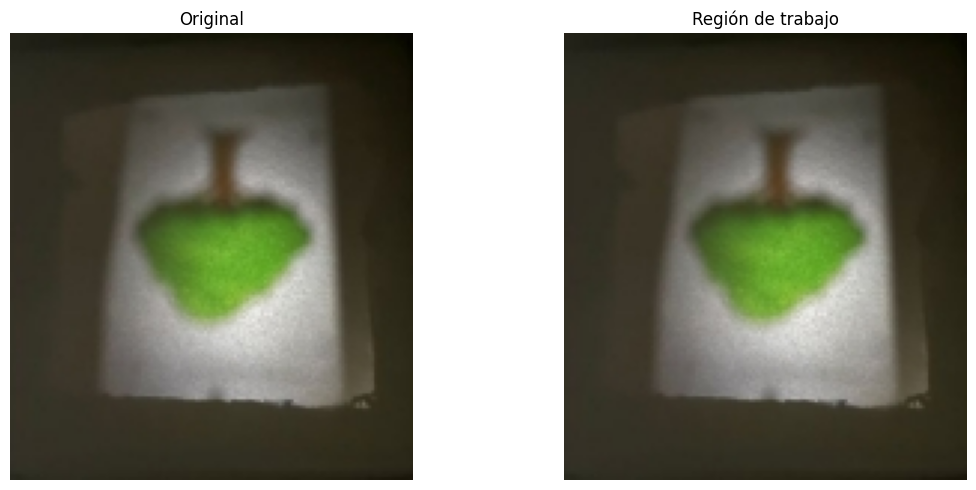

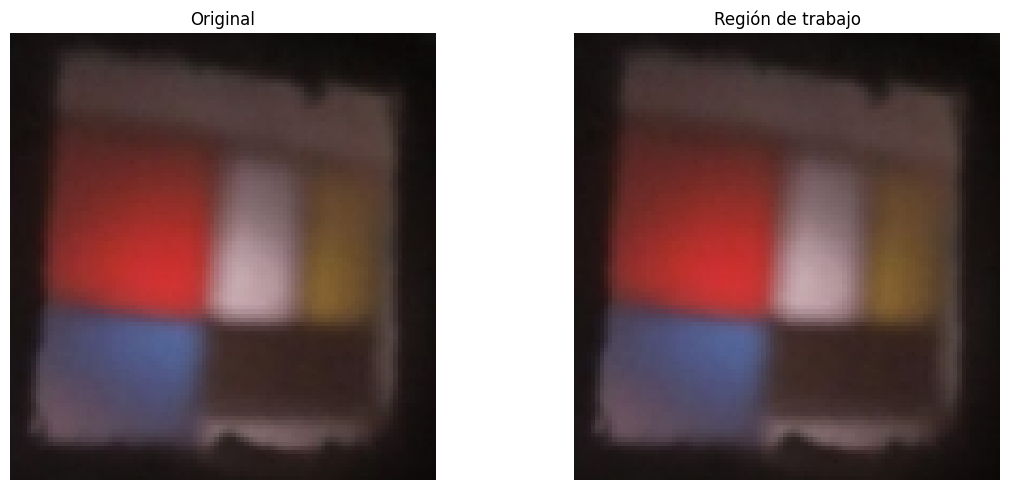

In [ ]:
# Si no querés recortar, usá toda la imagen.
y1, y2 = 0, imagen_original1.shape[0]
x1, x2 = 0, imagen_original1.shape[1]

imagen_recortada = imagen_original1[y1:y2, x1:x2]
mostrar_comparacion(imagen_original1, imagen_recortada, "Original", "Región de trabajo")
\
y1, y2 = 0, imagen_original2.shape[0]
x1, x2 = 0, imagen_original2.shape[1]

imagen_recortada = imagen_original2[y1:y2, x1:x2]
mostrar_comparacion(imagen_original2, imagen_recortada, "Original", "Región de trabajo")

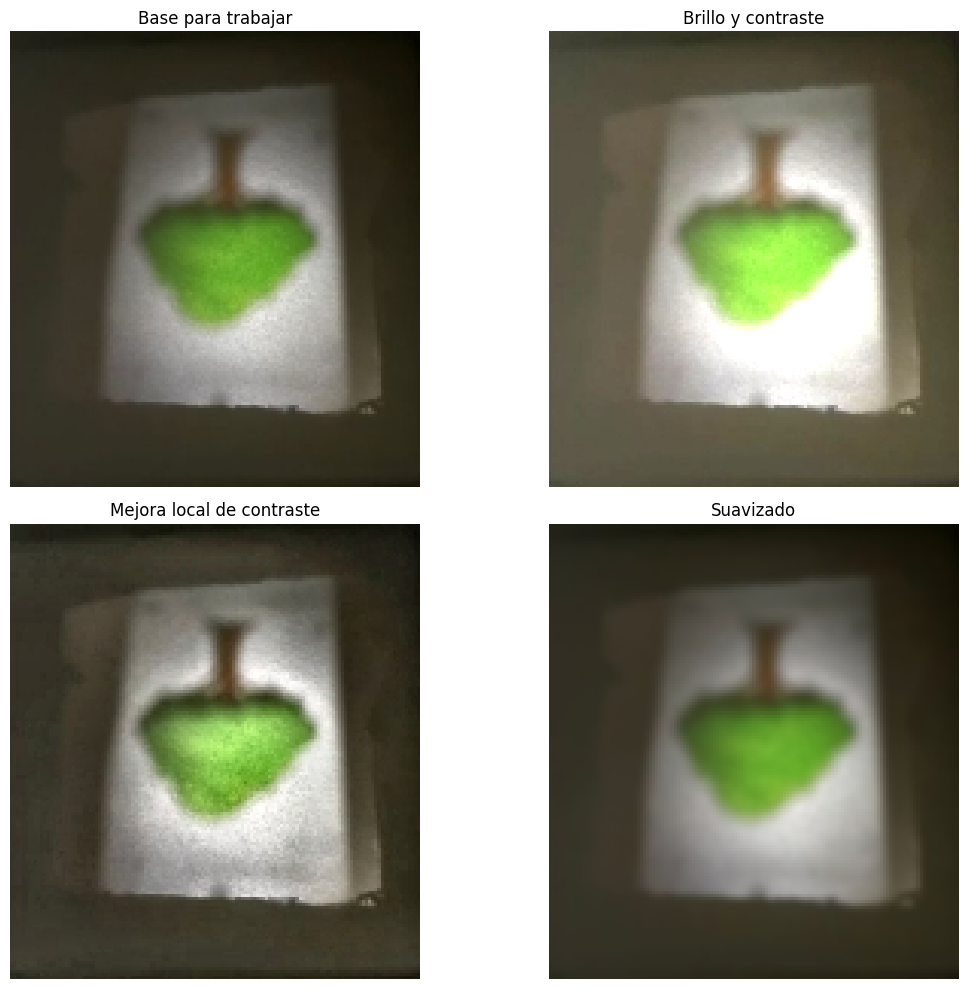

In [ ]:
brillo_contraste1 = ajustar_brillo_contraste(imagen_original1, alpha=1.4, beta=20)
clahe1 = mejorar_contraste_clahe(imagen_original1, clip_limit=2.0, tile=8)
suavizada1 = suavizar(imagen_original1, kernel=5)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(imagen_original1)
axes[0, 0].set_title("Base para trabajar")
axes[0, 0].axis("off")

axes[0, 1].imshow(brillo_contraste1)
axes[0, 1].set_title("Brillo y contraste")
axes[0, 1].axis("off")

axes[1, 0].imshow(clahe1)
axes[1, 0].set_title("Mejora local de contraste")
axes[1, 0].axis("off")

axes[1, 1].imshow(suavizada1)
axes[1, 1].set_title("Suavizado")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

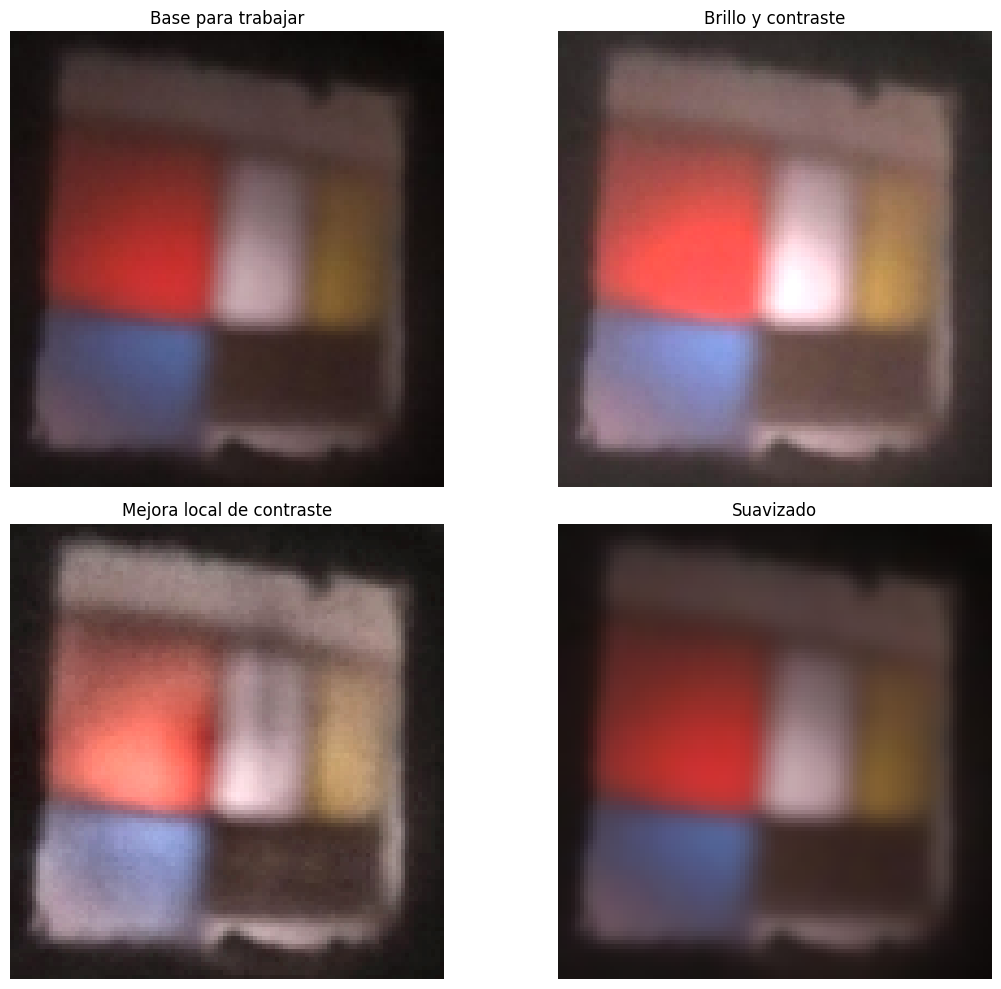

In [ ]:
brillo_contraste2 = ajustar_brillo_contraste(imagen_original2, alpha=1.4, beta=20)
clahe2 = mejorar_contraste_clahe(imagen_original2, clip_limit=2.0, tile=8)
suavizada2 = suavizar(imagen_original2, kernel=5)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(imagen_original2)
axes[0, 0].set_title("Base para trabajar")
axes[0, 0].axis("off")

axes[0, 1].imshow(brillo_contraste2)
axes[0, 1].set_title("Brillo y contraste")
axes[0, 1].axis("off")

axes[1, 0].imshow(clahe2)
axes[1, 0].set_title("Mejora local de contraste")
axes[1, 0].axis("off")

axes[1, 1].imshow(suavizada2)
axes[1, 1].set_title("Suavizado")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

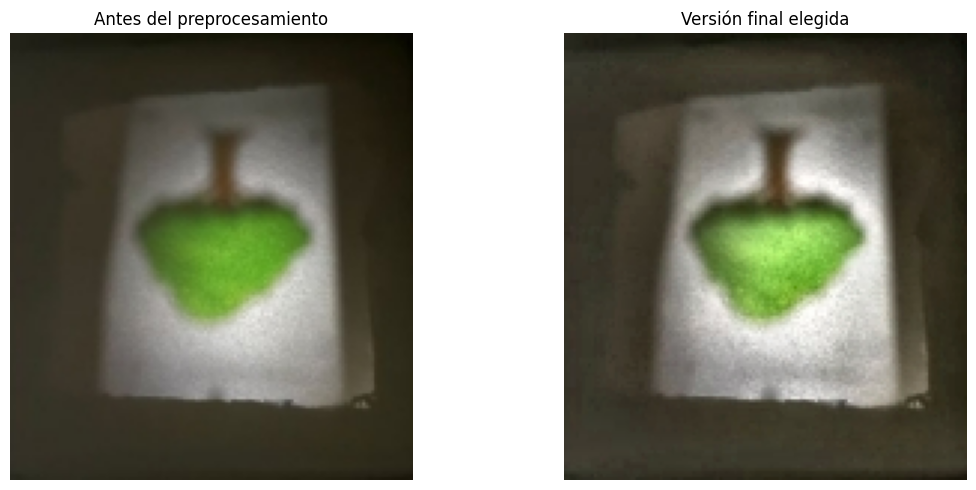

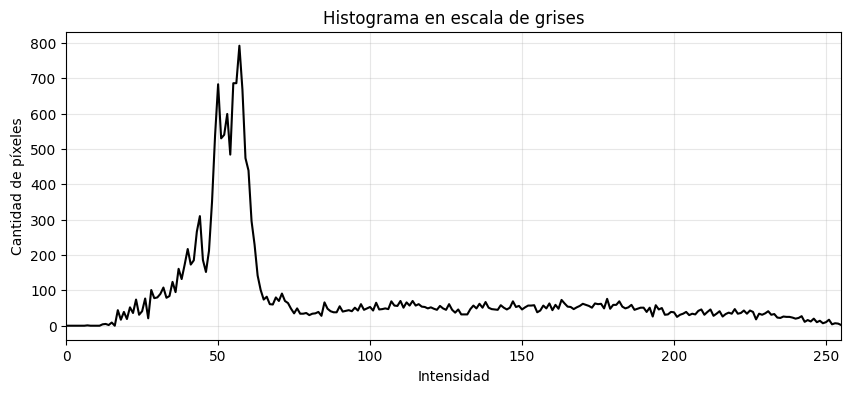

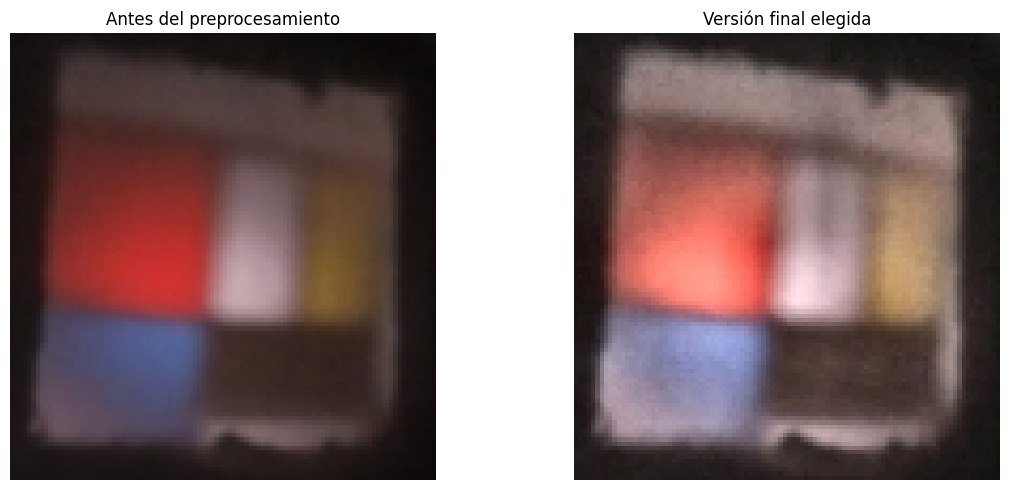

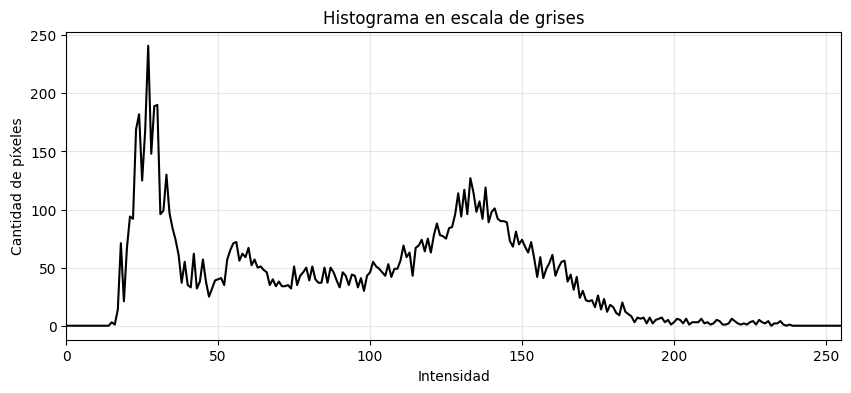

In [ ]:
# Elegí una opción o combiná operaciones.
imagen_preprocesada1 = clahe1

# Ejemplo de combinación posible:
# imagen_preprocesada = suavizar(ajustar_brillo_contraste(imagen_recortada, alpha=1.3, beta=15), kernel=5)

mostrar_comparacion(imagen_original1, imagen_preprocesada1, "Antes del preprocesamiento", "Versión final elegida")
mostrar_histograma_gris(imagen_preprocesada1)


imagen_preprocesada2 = clahe2

mostrar_comparacion(imagen_original2, imagen_preprocesada2, "Antes del preprocesamiento", "Versión final elegida")
mostrar_histograma_gris(imagen_preprocesada2)

In [ ]:
# Ruta de la carpeta donde se guardarán las imágenes preprocesadas
save_path = folder_path

# Guardar imagen_preprocesada1
nombre_guardar1 = str(save_path / "CAMARA-OSCURA-1_preprocesada.jpeg")
cv2.imwrite(nombre_guardar1, cv2.cvtColor(imagen_preprocesada1, cv2.COLOR_RGB2BGR))
print(f"Imagen preprocesada 1 guardada en: {nombre_guardar1}")

# Guardar imagen_preprocesada2
nombre_guardar2 = str(save_path / "CAMARA-OSCURA-2_preprocesada.jpeg")
cv2.imwrite(nombre_guardar2, cv2.cvtColor(imagen_preprocesada2, cv2.COLOR_RGB2BGR))
print(f"Imagen preprocesada 2 guardada en: {nombre_guardar2}")

Imagen preprocesada 1 guardada en: /content/drive/MyDrive/procesamiento digital de imagenes/CAMARA-OSCURA-1_preprocesada.jpeg
Imagen preprocesada 2 guardada en: /content/drive/MyDrive/procesamiento digital de imagenes/CAMARA-OSCURA-2_preprocesada.jpeg


### Análisis del Preprocesamiento de Imágenes

Ambas imágenes originales (`CAMARA-OSCURA-1.jpeg` y `CAMARA-OSCURA-2.jpeg`) eran algo oscuras y tenian poco contraste**. se veia en sus histogramas de grises, donde la mayoría de los píxeles se concentraban en el rango de baja intensidad (lado izquierdo del histograma). Esta falta de distribución amplia de intensidades significaba que no había una buena diferenciación entre las zonas claras y oscuras, haciendo que los detalles fueran difíciles de percibir.

Decidimos mejorar el ontraste (CLAHE - Contrast Limited Adaptive Histogram Equalization)

De esta forma se obtuvo Mayor luminosidad, haciendo visibles detalles que antes estaban ocultos en las sombras. mejor contraste, de forma que se noto clara distinción entre las diferentes regiones y objetos dentro de la imagen. Los bordes y las texturas se ven mas definidos.
El histograma de la imagen preprocesada (con CLAHE) mostró una distribución más uniforme y extendida a lo largo de todo el rango de intensidades (0-255), en contraste con el histograma original que estaba comprimido hacia las bajas intensidades para el caso de  en el caso de CAMARA-OSCURA-2.jpeg. No hubo mucha variacion en el caso del histograma de  en el caso de CAMARA-OSCURA-1.jpeg  


Esta nueva versión preprocesada es significativamente mejor para la segmentación por el realce de bordes y detalles ya que los algoritmos de  segmentación a menudo dependen de la detección de cambios abruptos en la intensidad de los píxeles (bordes) para delimitar objetos. Al mejorar el contraste, CLAHE realza estos bordes y hace que los detalles finos sean más prominentes, lo que facilita su detección.
Al distribuir las intensidades de los píxeles de manera más uniforme, se maximiza la diferencia de intensidad entre el objeto de interés y el fondo, o entre diferentes regiones dentro del objeto. Esto ayuda a los algoritmos a distinguir y separar diferentes elementos con mayor precisión.
En las imágenes originales oscuras y de bajo contraste, muchas regiones tenían intensidades similares, lo que podría confundir a un algoritmo de segmentación. La mejora del contraste reduce esta ambigüedad, permitiendo una clasificación de píxeles más fiable en las etapas de segmentación.

<br>


## **ACTIVIDAD 8**

In [ ]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_canales(imagen_rgb):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes[0, 0].imshow(imagen_rgb)
    axes[0, 0].set_title("Imagen original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(rojo, cmap="gray")
    axes[0, 1].set_title("Canal rojo")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(verde, cmap="gray")
    axes[1, 0].set_title("Canal verde")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(azul, cmap="gray")
    axes[1, 1].set_title("Canal azul")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


def mostrar_histogramas(imagen_rgb):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, indice, color, titulo in zip(
        axes,
        [0, 1, 2],
        ["red", "green", "blue"],
        ["Rojo", "Verde", "Azul"],
    ):
        hist, bins = np.histogram(imagen_rgb[:, :, indice].flatten(), bins=256, range=[0, 256])
        ax.plot(bins[:-1], hist, color=color)
        ax.set_title(f"Histograma {titulo}")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]
    mascara = (
        (rojo >= r_min) & (rojo <= r_max) &
        (verde >= g_min) & (verde <= g_max) &
        (azul >= b_min) & (azul <= b_max)
    )
    return mascara
archivos = {
    "flores": (
        Path("flowers.jpg"),
        "https://www.dropbox.com/s/jetlnfihles3g7k/flowers.jpg?dl=1",
    ),
    "frutos": (
        Path("frutos_rojos.png"),
        "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1",
    ),
}

for ruta, url in archivos.values():
    if not ruta.exists():
        urllib.request.urlretrieve(url, ruta)

if Path("imagen_preprocesada.png").exists():
    print("También está disponible: imagen_preprocesada.png")

print("Imágenes listas para la actividad.")

Imágenes listas para la actividad.


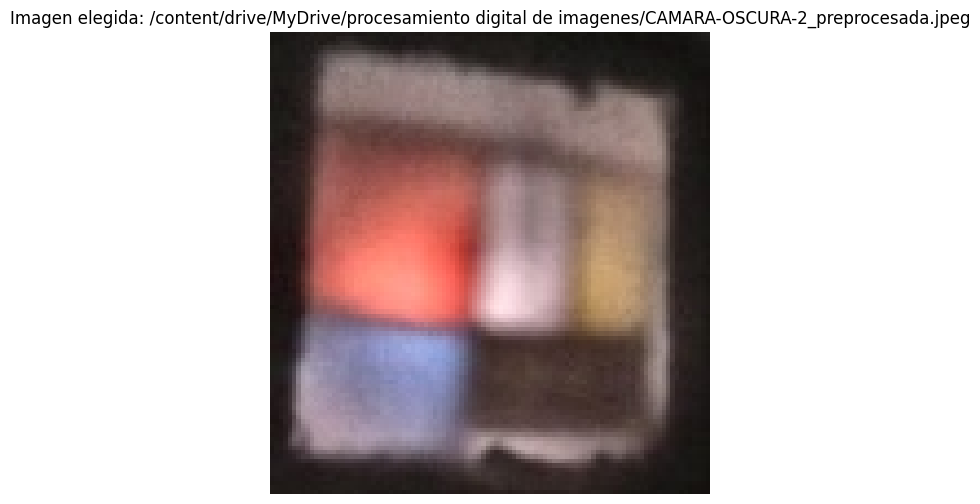

Color objetivo: Quiero resaltar el azul


In [ ]:
imagen_rgb = cargar_rgb(nombre_imagen_a_cargar)

# Escribí en una frase qué color querés segmentar.
color_objetivo = "Quiero resaltar el azul"

plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb)
plt.title(f"Imagen elegida: {nombre_imagen_a_cargar}")
plt.axis("off")
plt.show()

print("Color objetivo:", color_objetivo)

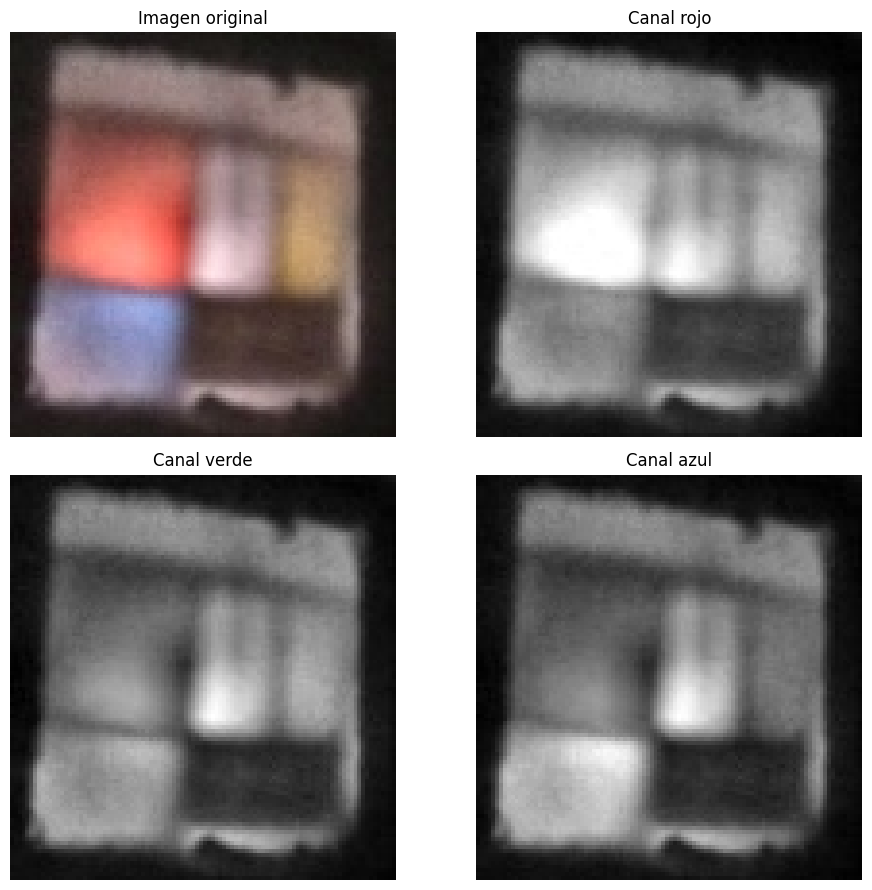

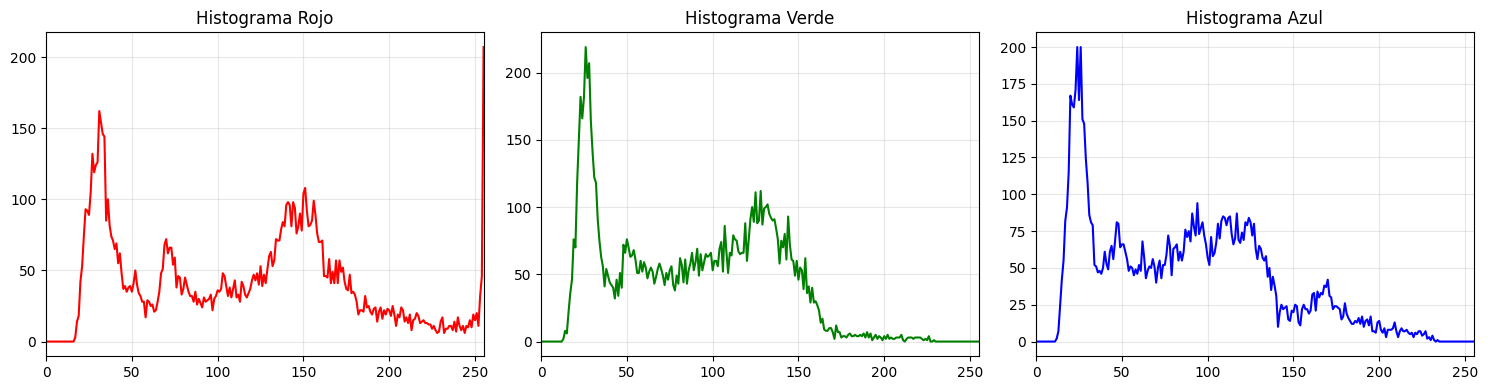

In [ ]:
mostrar_canales(imagen_rgb)
mostrar_histogramas(imagen_rgb)

# Escribí una observación breve sobre lo que viste.
observacion = ""
print(observacion)

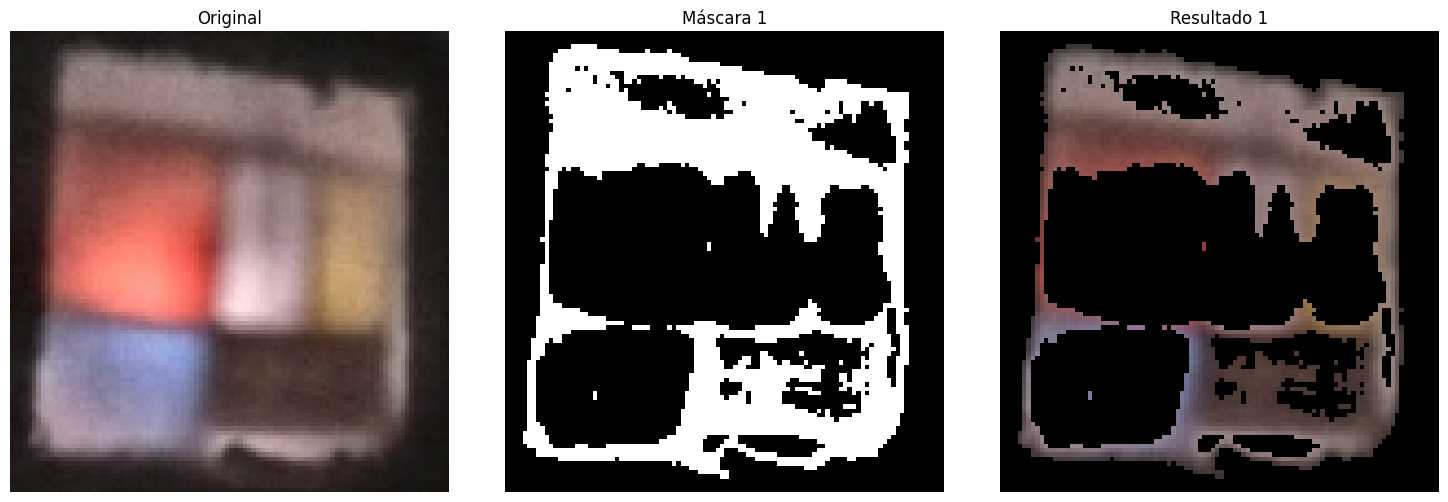

In [ ]:
r_min, r_max = 50, 150
g_min, g_max = 50, 150
b_min, b_max = 50, 150

mascara_1 = segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max)
resultado_1 = imagen_rgb.copy()
resultado_1[~mascara_1] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mascara_1, cmap="gray")
axes[1].set_title("Máscara 1")
axes[1].axis("off")

axes[2].imshow(resultado_1)
axes[2].set_title("Resultado 1")
axes[2].axis("off")

plt.tight_layout()
plt.show()

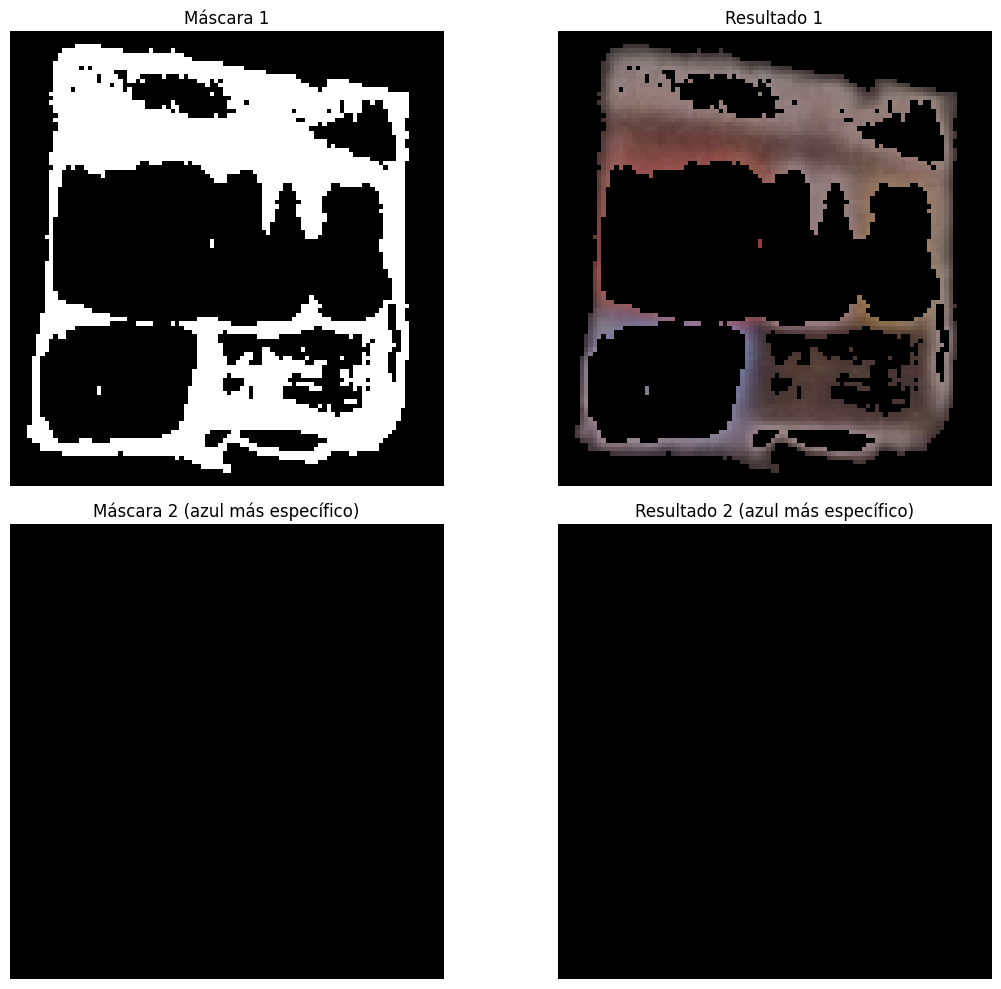

In [ ]:
r_min_2, r_max_2 = 0, 50
g_min_2, g_max_2 = 0, 50
b_min_2, b_max_2 = 180, 255

mascara_2 = segmentar_color(imagen_rgb, r_min_2, r_max_2, g_min_2, g_max_2, b_min_2, b_max_2)
resultado_2 = imagen_rgb.copy()
resultado_2[~mascara_2] = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(mascara_1, cmap="gray")
axes[0, 0].set_title("Máscara 1")
axes[0, 0].axis("off")

axes[0, 1].imshow(resultado_1)
axes[0, 1].set_title("Resultado 1")
axes[0, 1].axis("off")

axes[1, 0].imshow(mascara_2, cmap="gray")
axes[1, 0].set_title("Máscara 2 (azul más específico)")
axes[1, 0].axis("off")

axes[1, 1].imshow(resultado_2)
axes[1, 1].set_title("Resultado 2 (azul más específico)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

nos concentramos en aislar el color azul, haciéndolo progresivamente más específico.Utilizamos para la segmentacion, el canal del azul. Pero no obtuvimos un resultado satisfactorio.
La primera vez que intentamos el azul, establecimos rangos más amplios (por ejemplo, b_min_2 = 150, b_max_2 = 255, con r_max_2 y g_max_2 hasta 100). Para la segunda estrategia, que fue la más específica, estrechamos los rangos para los canales rojo y verde (r_max_2 = 50, g_max_2 = 50) y también ajustamos el rango del canal azul para enfocarnos en los tonos más brillantes (b_min_2 = 180, b_max_2 = 255). Esto ayudó a eliminar píxeles con componentes rojos o verdes significativos y a capturar solo los azules más puros.
Este método de segmentación por umbral de color en el espacio RGB es muy sensible a variaciones entre zonas iluminadas y oscuras. Un mismo color puede tener distintos valores RGB segun la luz. Esto hizo muy dificil separar colores con RGB similares.
Estamos desconcertados. El intento de aislar un color no funciono.
Consultamos Gemini para que nos oriente y nos sugirio:
Cambiar a espacios de color alternativos como HSV (Hue, Saturation, Value) o LAB, que a menudo separan mejor la crominancia (tono, saturación) de la luminancia (brillo). Esto puede hacer que la segmentación de colores sea más robusta a los cambios de iluminación.
Umbralización adaptativa: Para tener en cuenta las variaciones locales de iluminación, podría usar técnicas de umbralización adaptativa en lugar de un umbral global fijo.
Operaciones morfológicas: Aplicaría operaciones como la erosión y la dilatación para refinar las máscaras resultantes, eliminando pequeños ruidos y cerrando pequeños huecos en las regiones segmentadas.
Técnicas de segmentación más avanzadas: Para escenarios más complejos, consideraría algoritmos como Watershed o segmentación basada en clustering (por ejemplo, K-means) o incluso modelos de aprendizaje automático, que pueden manejar patrones de color y textura más complejos.